In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
print("Train:", train.shape, " Test:", test.shape)
train.head()

Train: (2051, 81)  Test: (879, 80)


,Id,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,SalePrice
0,109,533352170,60,RL,NaN,13517,Pave,NaN,IR1,Lvl,...,0,0,NaN,NaN,NaN,0,3,2010,WD,130500
1,544,531379050,60,RL,43.0,11492,Pave,NaN,IR1,Lvl,...,0,0,NaN,NaN,NaN,0,4,2009,WD,220000
2,153,535304180,20,RL,68.0,7922,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,NaN,0,1,2010,WD,109000
3,318,916386060,60,RL,73.0,9802,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,NaN,0,4,2010,WD,174000
4,255,906425045,50,RL,82.0,14235,Pave,NaN,IR1,Lvl,...,0,0,NaN,NaN,NaN,0,3,2010,WD,138500


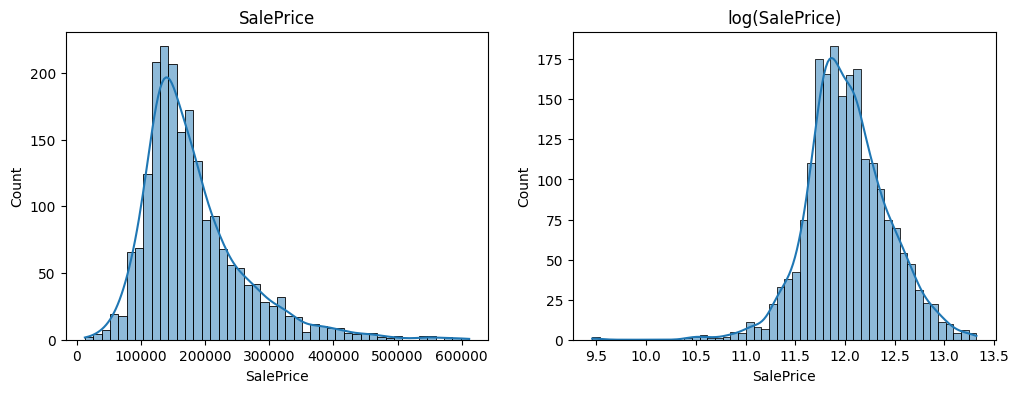

Skevhet före log: 1.56
Skevhet efter log: -0.15


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train["SalePrice"], kde=True, ax=ax[0])
ax[0].set_title("SalePrice")
sns.histplot(np.log(train["SalePrice"]), kde=True, ax=ax[1])
ax[1].set_title("log(SalePrice)")
plt.show()
print("Skevhet före log:", round(train["SalePrice"].skew(), 2))
print("Skevhet efter log:", round(np.log(train["SalePrice"]).skew(), 2))

SalePrice        1.00
Overall Qual     0.80
Gr Liv Area      0.70
Garage Area      0.65
Garage Cars      0.65
Total Bsmt SF    0.63
1st Flr SF       0.62
Year Built       0.57
Name: SalePrice, dtype: float64


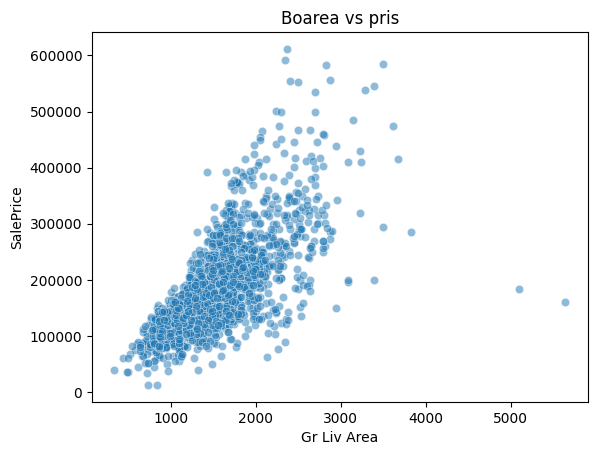

In [4]:
corr = train.select_dtypes(include=np.number).corr()["SalePrice"].sort_values(ascending=False)
print(corr.head(8).round(2))

sns.scatterplot(data=train, x="Gr Liv Area", y="SalePrice", alpha=0.5)
plt.title("Boarea vs pris")
plt.show()

In [5]:
train = train[~((train["Gr Liv Area"] > 4000) & (train["SalePrice"] < 300000))]
print("Train efter borttagning av extremvärden:", train.shape)

Train efter borttagning av extremvärden: (2049, 81)


In [6]:
def prepare(df):
    df = df.copy()
    none_cols = ["Pool QC", "Misc Feature", "Alley", "Fence", "Fireplace Qu", "Mas Vnr Type",
                 "Garage Type", "Garage Finish", "Garage Qual", "Garage Cond",
                 "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2"]
    df[none_cols] = df[none_cols].fillna("None")
    df["MS SubClass"] = df["MS SubClass"].astype(str)

    df["TotalSF"] = df["Total Bsmt SF"].fillna(0) + df["1st Flr SF"] + df["2nd Flr SF"]
    df["TotalBath"] = (df["Full Bath"] + 0.5 * df["Half Bath"]
                       + df["Bsmt Full Bath"].fillna(0) + 0.5 * df["Bsmt Half Bath"].fillna(0))
    df["HouseAge"] = df["Yr Sold"] - df["Year Built"]
    df["Qual_x_TotalSF"] = df["Overall Qual"] * df["TotalSF"]

    for c in ["Gr Liv Area", "Lot Area", "TotalSF", "Qual_x_TotalSF"]:
        df[c] = np.log1p(df[c])
    return df.drop(columns=["Id", "PID"])

X = prepare(train).drop(columns=["SalePrice"])
y = np.log(train["SalePrice"])
X_test = prepare(test)
print("X:", X.shape, " X_test:", X_test.shape)

X: (2049, 82)  X_test: (879, 82)


In [7]:
num_features = X.select_dtypes(include=np.number).columns
cat_features = X.select_dtypes(include="object").columns

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())]), num_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_features),
])

In [8]:
models = {
    "Ridge (bra modell)": Ridge(alpha=10),
    "Beslutsträd (sämre modell)": DecisionTreeRegressor(max_depth=6, random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    rmse = -cross_val_score(pipe, X, y, cv=kf, scoring="neg_root_mean_squared_error")
    print(f"{name}: RMSE (log) = {rmse.mean():.4f}  (+/- {rmse.std():.4f})")

Ridge (bra modell): RMSE (log) = 0.1175  (+/- 0.0111)
Beslutsträd (sämre modell): RMSE (log) = 0.1802  (+/- 0.0115)


In [9]:
final_model = Pipeline([("prep", preprocessor), ("model", Ridge(alpha=10))])
final_model.fit(X, y)

pred = np.exp(final_model.predict(X_test))
submission = pd.DataFrame({"Id": test["Id"], "SalePrice": pred})
submission.to_csv("submission.csv", index=False)
submission.head()

,Id,SalePrice
0,2658,119799.938271
1,2718,151016.951488
2,2414,219678.071924
3,1989,104200.084412
4,625,169364.747215
